# 2.1 Extended EDA on the merged dataset

`label_and_features.parquet` is the first point where the text layer and the market layer sit in
one table, and this notebook is the check that has to happen before any model touches it. We look
for whether the merge did what it claims, whether the labels and features carry the shape a
classifier can learn from, and whether anything here is corrupted, leaked, or missing in a way that
would make a later result fiction rather than a finding.

Nothing here trains a model. The output is a decision: proceed, clean something first, or go back
and fix the layer that produced the problem.

### 0. Setup

Imports and the one file this notebook reads: `label_and_features.parquet`, the merged table that
carries every article's text features alongside its market labels and market features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stock_predictor.config import PROCESSED_DATA_DIR

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

df = pd.read_parquet(PROCESSED_DATA_DIR / "label_and_features.parquet")
print("label_and_features:", df.shape)
df.head()

2026-08-25 14:01:12.334 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


label_and_features: (1976, 38)


,article_id,ticker,timestamp_utc,source,n_total_sents,n_entity_sents,n_ceo_sents,n_boilerplate_sents,entity_share,article_length,...,momentum_20d,prior_return_1d,volatility_20d,beta_20d,relative_volume_20d,daily_range_ratio_1d,days_to_earnings,session,news_volume,sentiment
0,138796882,TSLA,2025-08-22 08:13:15+00:00,Benzinga,19,1,0,5,0.052632,2611,...,0.075777,0.062166,0.023487,2.205253,1.196079,0.060469,61,pre-market,3,0.406216
1,136476320,TSLA,2025-08-22 10:40:18+00:00,Yahoo,26,4,0,0,0.153846,3256,...,0.075777,0.062166,0.023487,2.205253,1.196079,0.060469,61,pre-market,0,-0.034478
2,136476576,TSLA,2025-08-22 10:48:06+00:00,Yahoo,20,1,0,11,0.050000,3356,...,0.075777,0.062166,0.023487,2.205253,1.196079,0.060469,61,pre-market,1,-0.700990
3,138802535,TSLA,2025-08-22 11:10:13+00:00,Benzinga,32,4,0,5,0.125000,4997,...,0.075777,0.062166,0.023487,2.205253,1.196079,0.060469,61,market-hours,13,-0.337289
4,136476575,TSLA,2025-08-22 11:31:03+00:00,Yahoo,20,2,12,5,0.100000,3352,...,0.075777,0.062166,0.023487,2.205253,1.196079,0.060469,61,pre-market,2,-0.738242


### 1. Row-count check

148 articles were dropped by the text layer's relevance filter before the merge; that was diagnosed
and resolved in notebook 2.0. Here we only confirm the saved file survived: row and column count as
expected, no duplicate `article_id`, no rows lost on reload.

In [2]:
print("rows, cols:", df.shape)
print("unique article_id:", df["article_id"].nunique())
print("duplicate article_id rows:", df["article_id"].duplicated().sum())
print("expected row count (2,124 - 148 dropped by entity filter):", 2124 - 148)

rows, cols: (1976, 38)
unique article_id: 1976
duplicate article_id rows: 0
expected row count (2,124 - 148 dropped by entity filter): 1976


Matches: 1,976 rows, 1,976 unique `article_id`, no duplicates. The file reloads clean.

### 2. Labels and features

38 columns. Four are identity, three are labels, the rest are features split between the text layer
and the market layer.

**Identity**

| column | description |
|---|---|
| `article_id` | Join key, unique per row. |
| `ticker` | Target company the row was computed for. |
| `timestamp_utc` | Publication time. |
| `source` | Publisher name. |

**Labels**

| column | description |
|---|---|
| `abnormal_return_1d` | Ticker return minus SPY return, first trading day after publication. |
| `abnormal_return_3d` | Same, over a 3-day window. |
| `label_direction` | `sign(abnormal_return_1d)`. The 1-day classification target. |
| `label_direction_3d` | `sign(abnormal_return_3d)`. The 3-day classification target. `abnormal_return_3d` had no direction label saved in the file; this notebook adds one. |

**Features - text layer**

| column | description |
|---|---|
| `n_total_sents` | Sentences in the article after splitting. |
| `n_entity_sents` | Sentences tagged as being about the target, non-boilerplate. |
| `n_ceo_sents` | Sentences mentioning the CEO but not the target. |
| `n_boilerplate_sents` | Sentences whose exact text repeats across 5+ articles. |
| `entity_share` | `n_entity_sents` over the article's non-boilerplate sentence count. |
| `article_length` | Characters in the article as published. |
| `fus_conf_graft_floor_mean` | Mean fused sentiment score over target sentences. |
| `fus_conf_graft_floor_median` | Median of the same population. |
| `fus_conf_graft_floor_lead` | Mean fused score over target sentences in the opening window. |
| `fus_conf_graft_floor_top3_pos` | Mean of the 3 highest sentence scores. |
| `fus_conf_graft_floor_top3_neg` | Mean of the 3 lowest sentence scores. |
| `fus_conf_graft_floor_spread` | `top3_pos - top3_neg`. Contested vs. quiet article. |
| `fus_ceo_mean` | Mean fused score over CEO-only sentences. NaN where none exist. |
| `fus_headline` | The headline scored alone, both scorers grafted. |
| `fus_maxmag` | Signed score of the single loudest target sentence. |
| `fus_trusted_mean` | Mean fused score over the two most reliable provenance channels only. |
| `fus_scorer_gap` | Mean absolute disagreement between the two scorers. |
| `fus_headline_gap` | `fus_headline` minus the body mean. |
| `fus_lead_gap` | Lead score minus the body mean. |

**Features - market layer**

| column | description |
|---|---|
| `momentum_1d` / `5d` / `20d` | Pre-publication return over the trailing window. |
| `prior_return_1d` | Prior trading day's return. |
| `volatility_20d` | Rolling std of daily returns, pre-publication. |
| `beta_20d` | Rolling beta against SPY, pre-publication. |
| `relative_volume_20d` | Trading volume relative to its 20-day average. |
| `daily_range_ratio_1d` | Prior day's high-low range relative to price. |
| `days_to_earnings` | Calendar distance to the next earnings date. |
| `session` | `pre-market` / `market-hours` / `after-hours` at publication. |
| `news_volume` | Articles about the ticker in the prior 1-3 days. |

In [3]:
print("sentiment == fus_conf_graft_floor_mean, exactly:",
      (df["sentiment"] == df["fus_conf_graft_floor_mean"]).all())
print("label_direction == sign(abnormal_return_1d):",
      (np.sign(df["abnormal_return_1d"]) == df["label_direction"]).mean())

sentiment == fus_conf_graft_floor_mean, exactly: True
label_direction == sign(abnormal_return_1d): 1.0


`sentiment` is a byte-identical copy of `fus_conf_graft_floor_mean`, traced in notebook 2.0 to a
`.fillna(0.0)` alias built there for one scatter plot and then carried into the saved file. It adds
nothing and its `fillna` silently hides missingness, so we drop it. `label_direction` is exactly
`sign(abnormal_return_1d)`, confirming it is the 1-day label; `abnormal_return_3d` has no equivalent,
so we add `label_direction_3d` to match it.

In [4]:
df = df.drop(columns=["sentiment"])
df["label_direction_3d"] = np.sign(df["abnormal_return_3d"]).astype(int)

print("dropped: sentiment")
print("added: label_direction_3d", df["label_direction_3d"].value_counts().to_dict())
print("shape:", df.shape)

dropped: sentiment
added: label_direction_3d {1: 1127, -1: 849}
shape: (1976, 38)


### 3. Missingness

Which columns carry NaN, how much, and whether it clusters in a way that would need imputation or a
dropped column before training.

In [5]:
na_pct = (df.isna().sum() / len(df) * 100).round(1)
na_pct = na_pct[na_pct > 0].sort_values(ascending=False)
print("columns with any NaN:")
print(na_pct)
print()
print("NaNs per row:")
print(df.isna().sum(axis=1).value_counts().sort_index())

columns with any NaN:
fus_ceo_mean    50.6
dtype: float64

NaNs per row:
0    977
1    999
Name: count, dtype: int64


Only one column carries any NaN: `fus_ceo_mean`, missing on 50.6% of rows. That is not corruption,
it is the population being empty, an article with no CEO-only sentence has no CEO score to report,
as documented in the text layer. Every other feature and every label is fully
populated.

Leaving `fus_ceo_mean` as NaN is not quite the same as leaving it inert. LightGBM's split-finding is
NaN-aware: it learns which branch a missing value routes to, rather than requiring a numeric fill.
Filling with 0.0 would be actively wrong, for the same reason it is wrong everywhere else in this
table, 0.0 already means "measured, neutral," not "absent," and an empty CEO population is not a
neutral opinion about the CEO.

But that also means whether the CEO is mentioned at all could itself be predictive, independent of
what the score says when it exists. An article that brings the CEO in at all may carry different
market impact than one that stays narrowly on the company, whichever way `fus_ceo_mean` leans. NaN
alone does not separate those two effects for the model as cleanly as an explicit column does, so we
add one.

In [6]:
df["has_ceo_mention"] = df["fus_ceo_mean"].notna()

print("has_ceo_mention:", df["has_ceo_mention"].value_counts().to_dict())
print("fus_ceo_mean still NaN where absent, unfilled:",
      df.loc[~df["has_ceo_mention"], "fus_ceo_mean"].isna().all())

has_ceo_mention: {False: 999, True: 977}
fus_ceo_mean still NaN where absent, unfilled: True


977 articles carry a CEO mention, 999 don't, an even enough split to be worth a branch. The model
now gets two separate questions instead of one conflated one: whether the CEO was mentioned, from
`has_ceo_mention`, and what was said in relation to them when they were, from `fus_ceo_mean`, still NaN and
still untouched where there's nothing to score.

### 4. TSLA over the corpus period

Every label and feature in this table is derived from one thing: how TSLA's price actually moved.
Before reading anything into the numbers built on top of it, it's worth looking at the stock itself
over the window the corpus covers, close price against the article span, alongside SPY as the
benchmark the labels are measured against.

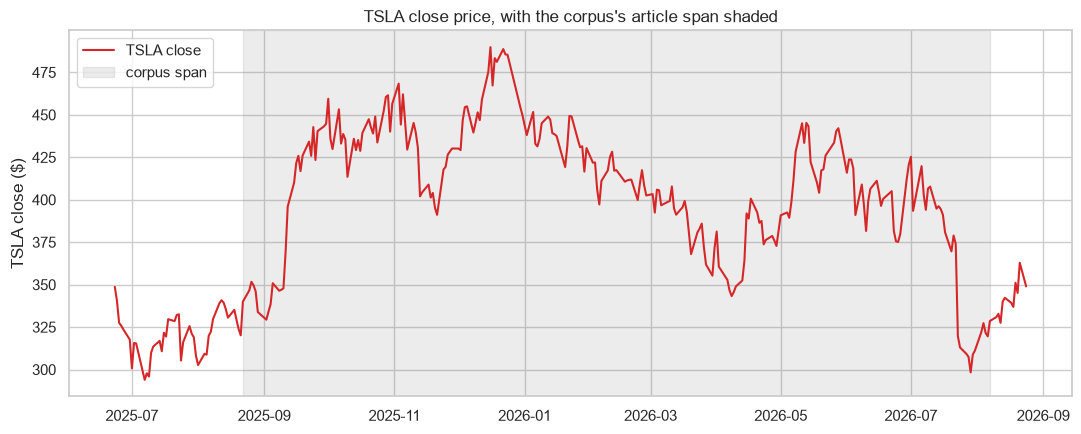

TSLA over the corpus span: 340.01 -> 328.58 (-3.36%), range 298.32-489.88
SPY  over the corpus span: 638.24 -> 773.26 (+21.16%)


In [7]:
from stock_predictor.config import RAW_DATA_DIR

ohlcv = pd.read_parquet(RAW_DATA_DIR / "raw_ohlcv.parquet")
tsla_close = ohlcv["Close"]["TSLA"]
spy_close = ohlcv["Close"]["SPY"]

corpus_start = df["timestamp_utc"].min().tz_localize(None).normalize()
corpus_end = df["timestamp_utc"].max().tz_localize(None).normalize()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tsla_close.index, tsla_close.values, label="TSLA close", color="tab:red")
ax.axvspan(corpus_start, corpus_end, color="grey", alpha=0.15, label="corpus span")
ax.set_ylabel("TSLA close ($)")
ax.set_title("TSLA close price, with the corpus's article span shaded")
ax.legend()
plt.tight_layout()
plt.show()

span = tsla_close.loc[corpus_start:corpus_end]
spy_span = spy_close.loc[corpus_start:corpus_end]
print(f"TSLA over the corpus span: {span.iloc[0]:.2f} -> {span.iloc[-1]:.2f} "
      f"({(span.iloc[-1] / span.iloc[0] - 1) * 100:+.2f}%), range {span.min():.2f}-{span.max():.2f}")
print(f"SPY  over the corpus span: {spy_span.iloc[0]:.2f} -> {spy_span.iloc[-1]:.2f} "
      f"({(spy_span.iloc[-1] / spy_span.iloc[0] - 1) * 100:+.2f}%)")

TSLA moved from $340.01 to $328.58 over the corpus span, -3.36%, after ranging as high as $489.88
and as low as $298.32 along the way, a volatile, roughly round-trip year rather than a steady move
in either direction. SPY rose 21.15% over the same span, so on a raw-return basis TSLA badly
underperformed the market.

### 5. Label balance

Whether `label_direction` and `label_direction_3d` sit near 50/50. A model that has to beat a
majority-class baseline near 50% is being tested honestly; one tested against a skewed label is not.

In [8]:
for col in ["label_direction", "label_direction_3d"]:
    counts = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    print(f"{col}: {counts.to_dict()}  ->  {pct.round(1).to_dict()}")

print()
print("tickers in the table:", df["ticker"].unique().tolist())
print("1d/3d direction agreement:", (df["label_direction"] == df["label_direction_3d"]).mean())

label_direction: {1: 996, -1: 980}  ->  {1: 50.4, -1: 49.6}
label_direction_3d: {1: 1127, -1: 849}  ->  {1: 57.0, -1: 43.0}

tickers in the table: ['TSLA']
1d/3d direction agreement: 0.6624493927125507


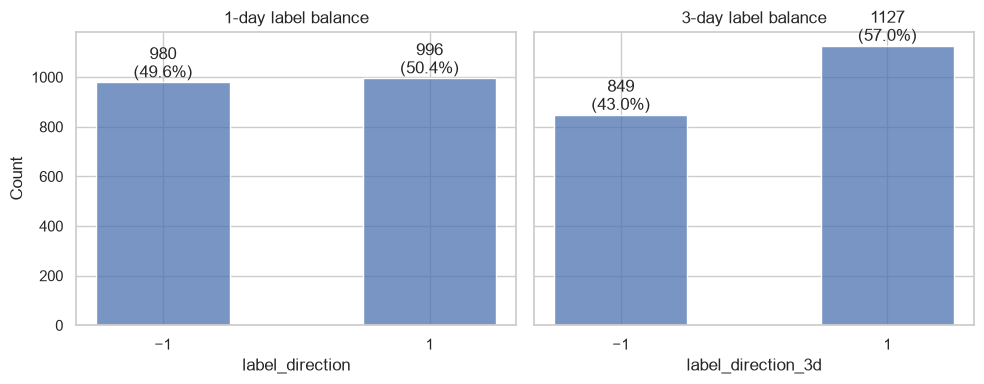

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col, title in zip(axes, ["label_direction", "label_direction_3d"], ["1-day", "3-day"]):
    sns.histplot(df[col], bins=2, discrete=True, ax=ax)
    ax.set_title(f"{title} label balance")
    ax.set_xticks([-1, 1])
    for x, n in df[col].value_counts().items():
        ax.text(x, n, f"{n}\n({n/len(df):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.show()

`label_direction` sits at 50.4% / 49.6%, as close to balanced as a real corpus gets. `label_direction_3d`
is looser, 57.0% / 43.0%. The two labels agree on sign for 66.2% of rows, so a third of the corpus
reverses or extends between day 1 and day 3, which is itself the horizon question the analysis phase
exists to answer, not a defect here.

Both skew positive, and the 3-day one skews harder, which is odd set against section 4: TSLA fell
3.36% over this span while SPY rose 21.15%, so the stock underperformed the market outright. A label
built from ticker-minus-SPY return should, if anything, lean negative on a stock that badly
underperformed its benchmark. It leans positive instead, and more so at the longer horizon. That is
worth investigating rather than waving away.

### 6. Article volume, abnormal return, and where the positive skew actually comes from

Two candidate explanations for section 5's question. Either the corpus is unevenly sampled, more
articles landing during whatever stretch of the year was going TSLA's way, or the abnormal returns
themselves are asymmetric between the rally and the decline. We check volume first.

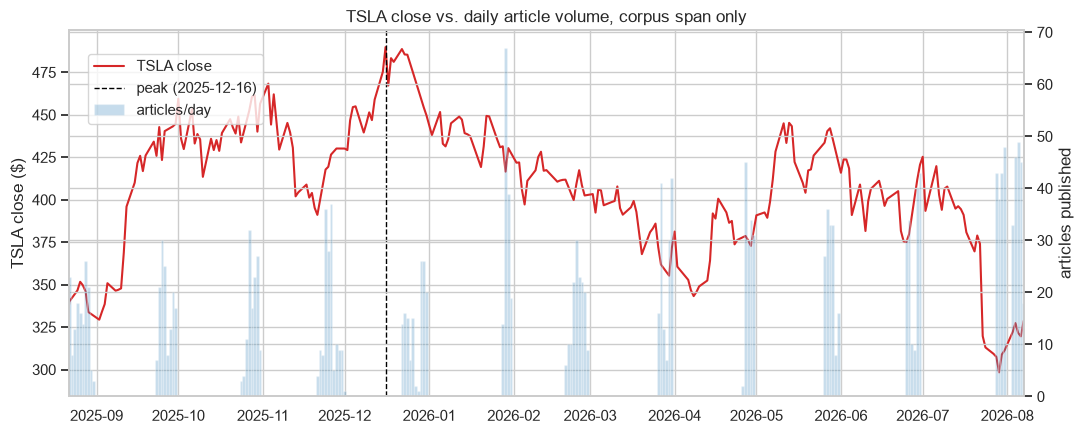

In [10]:
ts = df["timestamp_utc"].dt.tz_localize(None)
daily_articles = ts.dt.normalize().value_counts().sort_index().reindex(
    pd.date_range(corpus_start, corpus_end, freq="D"), fill_value=0
)
peak_date = span.idxmax()

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(tsla_close.index, tsla_close.values, color="tab:red", label="TSLA close")
ax1.axvline(peak_date, color="black", linestyle="--", linewidth=1, label=f"peak ({peak_date.date()})")
ax1.set_ylabel("TSLA close ($)")
ax2 = ax1.twinx()
ax2.bar(daily_articles.index, daily_articles.values, color="tab:blue", alpha=0.25, width=1.0, label="articles/day")
ax2.set_ylabel("articles published")
ax1.set_xlim(corpus_start, corpus_end)
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
ax1.set_title("TSLA close vs. daily article volume, corpus span only")
plt.tight_layout()
plt.show()

Article volume, the blue bars, does not visibly track the price line. Bars sit at similar heights
whether the red line is climbing toward the December peak or sliding back down afterward, and the
gaps between clusters look unrelated to the direction TSLA happened to be moving that stretch. That
reads as no obvious relationship. The more striking feature of the chart is the bars themselves, not
their height, but how few of them there are.

**Limitation.** The bars above are not sparse by chance. Only 92 of the 351 days in the corpus span
carry any article at all, and the empty runs between them stretch as long as 27 consecutive days.
The active days cluster at the tail end of each calendar month, four to eleven days wide, with a
consistent 126-191 articles per month regardless of how wide that window is. That shape matches the
Finnhub `company_news` collection loop hitting its per-call result cap and filling it from the most
recent news first, rather than covering the month evenly. The corpus is effectively 13 short bursts
of recent news, not a continuous year of coverage.

This is noted here as a limitation to carry forward, not resolved in this notebook. It puts a
question mark over `news_volume`, since "articles in the prior 1-3 days" is measured against gaps
that are collection artefacts rather than genuinely quiet news periods, and it means any per-day rate
computed over the full span is dividing by mostly-empty calendar days rather than active ones.

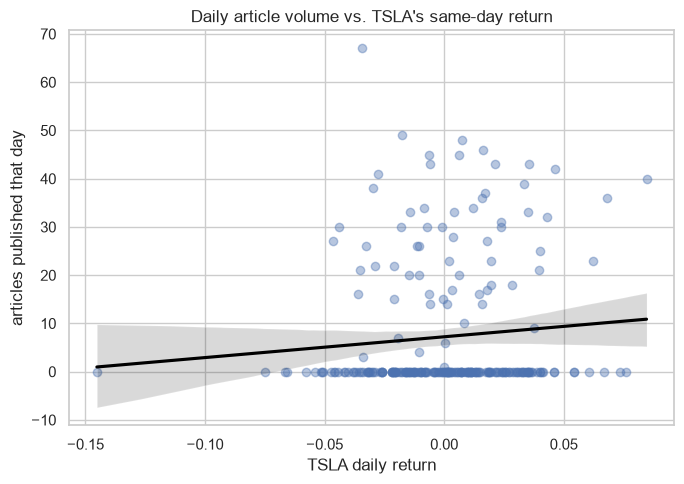

corr(article volume, same-day return): 0.09312729553781937

climb   (2025-08-22 -> 2025-12-16, 117 days): 570 articles, 4.87/day
descent (2025-12-16 -> 2026-08-07, 235 days): 1406 articles, 5.98/day


In [11]:
daily_ret = tsla_close.pct_change().reindex(daily_articles.index)
vol_vs_ret = pd.DataFrame({"n_articles": daily_articles, "daily_return": daily_ret}).dropna()

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=vol_vs_ret, x="daily_return", y="n_articles", ax=ax,
            scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
ax.set_title("Daily article volume vs. TSLA's same-day return")
ax.set_xlabel("TSLA daily return")
ax.set_ylabel("articles published that day")
plt.tight_layout()
plt.show()

print("corr(article volume, same-day return):", vol_vs_ret["n_articles"].corr(vol_vs_ret["daily_return"]))
print()
climb_mask = ts <= peak_date
n_climb_days = (peak_date - corpus_start).days + 1
n_descent_days = (corpus_end - peak_date).days + 1
print(f"climb   ({corpus_start.date()} -> {peak_date.date()}, {n_climb_days} days): "
      f"{climb_mask.sum()} articles, {climb_mask.sum() / n_climb_days:.2f}/day")
print(f"descent ({peak_date.date()} -> {corpus_end.date()}, {n_descent_days} days): "
      f"{(~climb_mask).sum()} articles, {(~climb_mask).sum() / n_descent_days:.2f}/day")

Volume is not the answer. Article count barely correlates with the same-day return, 0.09, and the
descent, the longer and worse-performing half, carries the busier news flow: 5.98 articles/day
against 4.87/day during the climb. If anything, uneven sampling should pull the labels toward the
descent, not away from it. The skew has to come from somewhere else.

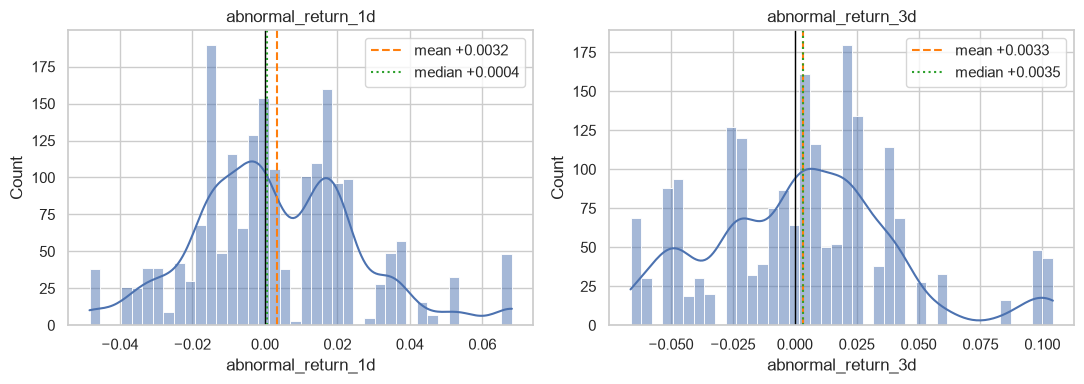

       abnormal_return_1d  abnormal_return_3d
count           1976.0000           1976.0000
mean               0.0032              0.0033
std                0.0230              0.0379
min               -0.0484             -0.0664
25%               -0.0139             -0.0228
50%                0.0004              0.0035
75%                0.0180              0.0248
max                0.0681              0.1043


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["abnormal_return_1d", "abnormal_return_3d"]):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(df[col].mean(), color="tab:orange", linestyle="--", label=f"mean {df[col].mean():+.4f}")
    ax.axvline(df[col].median(), color="tab:green", linestyle=":", label=f"median {df[col].median():+.4f}")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

print(df[["abnormal_return_1d", "abnormal_return_3d"]].describe().round(4))

Both distributions are roughly bell-shaped and centred near zero, which is what a return series
should look like. `abnormal_return_3d` is visibly wider than `abnormal_return_1d`, std 0.0379
against 0.0230, the expected effect of accumulating price movement over a longer window.

The mean/median gap is the useful read here. At 1 day the median sits at +0.0004, essentially on
top of zero, matching section 5's near-50/50 label split directly: half the mass really is just
above and half just below the line. At 3 days the median sits at +0.0035, visibly to the right of
zero, and that shift is what section 5's 57/43 split looks like as a distribution rather than a
count. The histograms are not yet an explanation for the shift; they only confirm the two label
balances are reading their own distributions correctly.

In [13]:
for horizon, col in [("1d", "abnormal_return_1d"), ("3d", "abnormal_return_3d")]:
    climb_mean = df.loc[climb_mask, col].mean()
    descent_mean = df.loc[~climb_mask, col].mean()
    climb_pos = (df.loc[climb_mask, col] > 0).mean()
    descent_pos = (df.loc[~climb_mask, col] > 0).mean()
    print(f"{horizon}: climb mean {climb_mean:+.4f} ({climb_pos:.1%} positive, n={climb_mask.sum()})  "
          f"|  descent mean {descent_mean:+.4f} ({descent_pos:.1%} positive, n={(~climb_mask).sum()})")

1d: climb mean +0.0083 (65.1% positive, n=570)  |  descent mean +0.0011 (44.5% positive, n=1406)
3d: climb mean +0.0120 (68.8% positive, n=570)  |  descent mean -0.0002 (52.3% positive, n=1406)


This is the answer. Climb-period articles average +0.83% abnormal return at 1 day and +1.20% at 3
days, with 65.1% and 68.8% positive respectively. Descent-period articles average close to flat,
+0.11% and -0.02%, with positive rates near 44-52%, roughly what a coin flip on a mildly falling
stock should look like.

Both are real. TSLA's climb was a sharp, fast, 116-day rally, and its descent was a slower, choppier
234-day slide covering more than twice the calendar time. The climb articles carry a strong,
consistent positive tilt; the descent articles, spread across a longer and noisier period, wash out
close to neutral rather than mirroring the climb's tilt in reverse. Pool 570 strongly-positive
observations against 1,406 near-neutral ones and the weighted average comes out positive, which is
exactly the label balance measured in section 5, and exactly why the 3-day label skews harder: the
climb's tilt is even stronger at 3 days (+1.20% vs +0.83%) while the descent stays roughly flat at
both horizons.

The skew is not a labelling bug and not an artefact of article sampling. It is a property of this
specific year for this specific stock: one sharp rally and one long grind, unevenly weighted by
how strongly each half of the story moved. It should not be rebalanced away, but it is worth
remembering when reading model performance later, since a classifier trained on this corpus is
partly learning "the climb was easy to call" rather than TSLA news in general.

**Takeaway.** The positive skew comes from consistency, not window size or article count: the climb
was fast and directionally consistent enough that a short forward window reliably landed on a gain,
while the descent, though longer, was choppy rather than steadily down, so the same short window
lands close to flat more often than it lands negative.

### 7. Market feature sanity

Ranges, degenerate columns, and whether the trading-calendar collapse from section 4's corpus-gap
limitation shows up here too.

In [14]:
market_cols = ["momentum_1d", "momentum_5d", "momentum_20d", "prior_return_1d", "volatility_20d",
               "beta_20d", "relative_volume_20d", "daily_range_ratio_1d", "days_to_earnings", "news_volume"]
print(df[market_cols].describe().T.round(4))
print()

active_days = ts.dt.normalize().nunique()
print(f"active calendar days: {active_days}, distinct market-feature value-sets: {df['momentum_1d'].nunique()}")

weekday_active = ts.dt.normalize().drop_duplicates().dt.dayofweek
print(f"of which weekend (Sat/Sun): {(weekday_active >= 5).sum()} of {len(weekday_active)}")
print()
print("session:", df["session"].value_counts().to_dict())
print()
print("momentum_1d == prior_return_1d, exactly:", (df["momentum_1d"] == df["prior_return_1d"]).all())

                       count     mean      std     min      25%      50%  \
momentum_1d           1976.0   0.0056   0.0286 -0.0464  -0.0143   0.0040   
momentum_5d           1976.0   0.0002   0.0615 -0.2024  -0.0352   0.0100   
momentum_20d          1976.0  -0.0206   0.1461 -0.2907  -0.1096  -0.0429   
prior_return_1d       1976.0   0.0056   0.0286 -0.0464  -0.0143   0.0040   
volatility_20d        1976.0   0.0295   0.0067  0.0202   0.0236   0.0286   
beta_20d              1976.0   2.3370   0.8749  1.0422   1.7673   2.1334   
relative_volume_20d   1976.0   0.9923   0.1905  0.4261   0.8535   0.9986   
daily_range_ratio_1d  1976.0   0.0352   0.0135  0.0156   0.0234   0.0332   
days_to_earnings      1976.0  57.6624  24.3259  0.0000  29.0000  58.0000   
news_volume           1976.0  61.8386  35.4520  0.0000  36.7500  58.0000   

                          75%       max  
momentum_1d            0.0213    0.0846  
momentum_5d            0.0429    0.1325  
momentum_20d           0.0703    0.35

Nothing here is degenerate. Every rolling feature stays strictly positive where it should
(`volatility_20d`, `relative_volume_20d`, `daily_range_ratio_1d`), `days_to_earnings` sits in
[0, 96], a plausible span against a roughly quarterly cycle, and `session` splits three ways without
one bucket swallowing the rest (774 / 741 / 461).

`momentum_1d` and `prior_return_1d` are byte-identical, the same 1-day return computed twice under
two names. Unlike `sentiment` in section 2 this one is harmless rather than misleading, since both
names describe the same quantity honestly, but it is a duplicate column and worth collapsing to one
before training for the same reason: no point letting a tree split on the same information twice
under different names.

92 active calendar days collapse to 68 distinct market-feature value-sets, and 25 of the 92 are
weekends. That is the trading calendar working as intended: an article published on a Saturday
inherits Friday's close-of-day features rather than getting features that don't exist for a
non-trading day, so several calendar days legitimately share one feature row. This is a different
mechanism from section 4's collection-gap limitation, not a symptom of it; it would happen even in a
corpus with continuous daily coverage.

**Flag for later: `beta_20d`.** It runs unusually high, mean 2.34 and a peak of 5.67 on 2026-07-28,
well above TSLA's textbook beta of 1.5-2. A 20-day rolling window is short enough that a single
volatile stretch can push it there, so this reads as noisy rather than wrong and is not being fixed
here. Action item: once the LightGBM models are trained (sentiment + market features first, then
FinBERT embeddings + market features), check `beta_20d`'s position in the feature-importance plot.
Low importance, ignore it. High importance, come back and check whether the model is learning a real
risk signal or fitting the noise in that one spiky window.

In [15]:
df = df.drop(columns=["prior_return_1d"])

print("dropped: prior_return_1d (duplicate of momentum_1d)")
print("shape:", df.shape)

dropped: prior_return_1d (duplicate of momentum_1d)
shape: (1976, 38)


### 8. Sentiment vs. return

The question the whole project rests on: does `fus_conf_graft_floor_mean`, the primary fused
sentiment score, carry any relationship to the return it is meant to predict. We check the raw
correlation first, then whether a coarser view, quintile buckets, shows something a linear
correlation would miss.

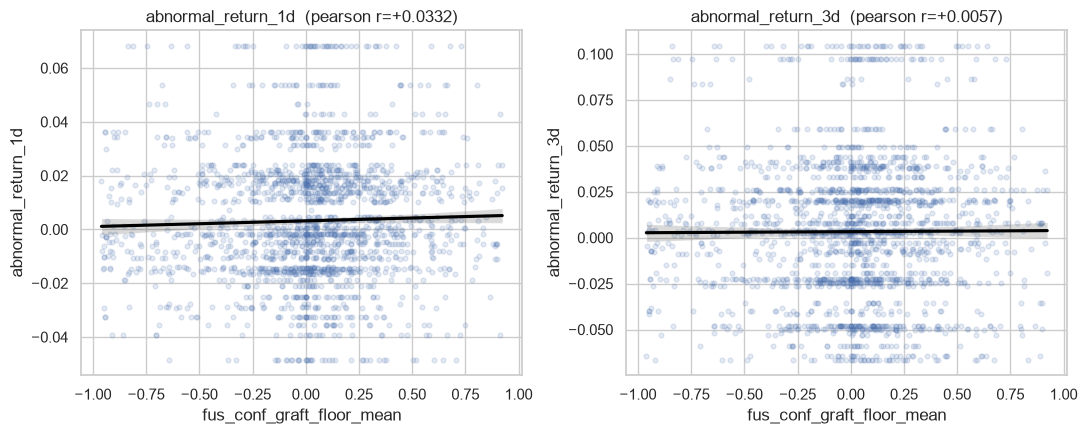

pearson correlation with abnormal_return_1d / 3d, every sentiment variant:
  fus_conf_graft_floor_mean        1d=+0.0332  3d=+0.0057
  fus_conf_graft_floor_median      1d=+0.0292  3d=-0.0036
  fus_conf_graft_floor_top3_pos    1d=+0.0434  3d=+0.0197
  fus_conf_graft_floor_top3_neg    1d=+0.0210  3d=-0.0015
  fus_conf_graft_floor_spread      1d=+0.0167  3d=+0.0167
  fus_headline                     1d=+0.0462  3d=+0.0092
  fus_maxmag                       1d=+0.0197  3d=-0.0150
  fus_trusted_mean                 1d=+0.0356  3d=+0.0058
  fus_scorer_gap                   1d=+0.0312  3d=+0.0439

directional accuracy (sign match), fus_conf_graft_floor_mean: 1d=0.5324  3d=0.4965


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, ["abnormal_return_1d", "abnormal_return_3d"]):
    sns.regplot(data=df, x="fus_conf_graft_floor_mean", y=col, ax=ax,
                scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "black"})
    r = df["fus_conf_graft_floor_mean"].corr(df[col])
    ax.set_title(f"{col}  (pearson r={r:+.4f})")
plt.tight_layout()
plt.show()

sent_cols = ["fus_conf_graft_floor_mean", "fus_conf_graft_floor_median", "fus_conf_graft_floor_top3_pos",
             "fus_conf_graft_floor_top3_neg", "fus_conf_graft_floor_spread", "fus_headline",
             "fus_maxmag", "fus_trusted_mean", "fus_scorer_gap"]
print("pearson correlation with abnormal_return_1d / 3d, every sentiment variant:")
for c in sent_cols:
    r1 = df[c].corr(df["abnormal_return_1d"])
    r3 = df[c].corr(df["abnormal_return_3d"])
    print(f"  {c:32s} 1d={r1:+.4f}  3d={r3:+.4f}")

pred = np.sign(df["fus_conf_graft_floor_mean"])
acc1 = (pred == df["label_direction"]).mean()
acc3 = (pred == df["label_direction_3d"]).mean()
print(f"\ndirectional accuracy (sign match), fus_conf_graft_floor_mean: 1d={acc1:.4f}  3d={acc3:.4f}")

The scatter is a haze, as a raw correlation of 0.033 (1d) and 0.006 (3d) implies it should be. No
variant does much better; `fus_headline` peaks at 0.046 and `fus_scorer_gap`, a disagreement measure
rather than a sentiment score, does best at 3 days with 0.044. None of that is a linear relationship
worth trusting on its own.

The directional-accuracy number is the more honest read for a signal this weak: 53.2% at 1 day, a
real edge over a coin flip on a task where anything above roughly 70% would itself be suspicious
rather than impressive. At 3 days it drops to 49.7%, indistinguishable from a coin flip. Read
together with section 6, this fits the same shape: whatever the climb-period articles were doing
right, it fades by day 3, since even sentiment's raw directional edge over a coin flip disappears at
that horizon.

                 n  mean_sentiment  mean_ar_1d  mean_ar_3d  pos_rate_1d
sent_quintile                                                          
Q1 (most neg)  396         -0.5206      0.0031      0.0038       0.4646
Q2             395         -0.1020      0.0008      0.0020       0.4430
Q3             395          0.0379      0.0045      0.0032       0.5494
Q4             395          0.1793      0.0029      0.0028       0.4886
Q5 (most pos)  395          0.4918      0.0048      0.0047       0.5747


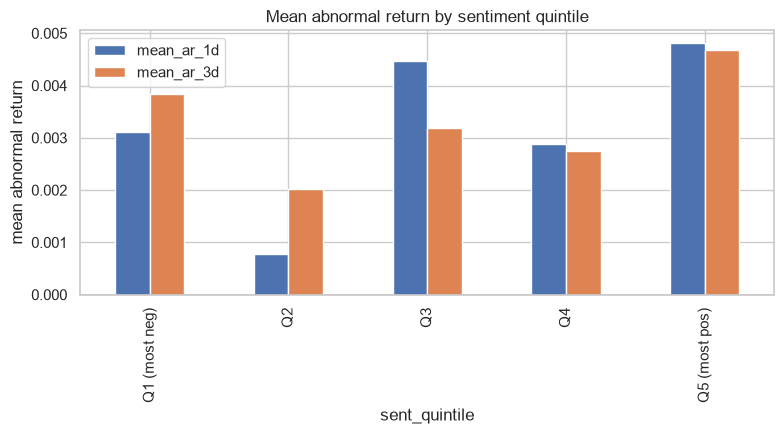

In [17]:
df["sent_quintile"] = pd.qcut(df["fus_conf_graft_floor_mean"], 5,
                               labels=["Q1 (most neg)", "Q2", "Q3", "Q4", "Q5 (most pos)"])
q = df.groupby("sent_quintile", observed=True).agg(
    n=("article_id", "count"),
    mean_sentiment=("fus_conf_graft_floor_mean", "mean"),
    mean_ar_1d=("abnormal_return_1d", "mean"),
    mean_ar_3d=("abnormal_return_3d", "mean"),
    pos_rate_1d=("label_direction", lambda x: (x == 1).mean()),
)
print(q.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
q[["mean_ar_1d", "mean_ar_3d"]].plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("mean abnormal return")
ax.set_title("Mean abnormal return by sentiment quintile")
plt.tight_layout()
plt.show()

Roughly a slope, not a clean one. Q1 to Q5 mean 1-day abnormal return runs 0.0031 -> 0.0008 ->
0.0045 -> 0.0029 -> 0.0048, and `pos_rate_1d` runs 46.5% -> 44.3% -> 54.9% -> 48.9% -> 57.5%. The
most negative and most positive quintiles sit roughly where a real relationship would put them, Q1
low, Q5 high, but Q2 through Q4 do not move monotonically, which a genuine linear signal should. That
is consistent with the 0.033 correlation: a real but weak tilt at the extremes, buried in enough
noise that the middle of the distribution does not resolve cleanly.

**Does the 53.2% edge live only in the climb period?** Section 6 found the climb was easier to call
than the descent on the market side alone. Worth checking whether sentiment's directional accuracy
shows the same split, since if the whole edge sits in the climb, section 8's "real signal" claim
would need qualifying.

In [18]:
pred = np.sign(df["fus_conf_graft_floor_mean"])
for label, mask in [("climb", climb_mask), ("descent", ~climb_mask)]:
    acc1 = (pred[mask] == df.loc[mask, "label_direction"]).mean()
    acc3 = (pred[mask] == df.loc[mask, "label_direction_3d"]).mean()
    r1 = df.loc[mask, "fus_conf_graft_floor_mean"].corr(df.loc[mask, "abnormal_return_1d"])
    print(f"{label:8s} (n={mask.sum():4d}): directional acc 1d={acc1:.4f}  3d={acc3:.4f}   corr_1d={r1:+.4f}")

climb    (n= 570): directional acc 1d=0.5544  3d=0.5509   corr_1d=-0.0081
descent  (n=1406): directional acc 1d=0.5235  3d=0.4744   corr_1d=+0.0392


Not a climb-only artefact, and more interesting than that. Directional accuracy is *higher* during
the climb, 55.4% at both 1d and 3d, than during the descent, 52.4% at 1d and 47.4% at 3d, the last of
which is below a coin flip. So sentiment works better precisely where section 6 said the market
itself was easier to call, which is a consistent story rather than a coincidence: an unambiguous
rally gives both the price and the sentiment scorer an easier target to agree on. The raw correlation
disagrees with the accuracy split, though, running negative in the climb (-0.008) and positive in the
descent (+0.039), which is a reminder that a linear correlation and a sign-match rate are measuring
different things and can point opposite ways on a signal this weak.

The descent's 3d accuracy sitting below chance is worth explaining rather than just flagging. By day
3, several more articles have typically been published about the same unfolding story, so any one
article's sentiment is competing with, and often overtaken by, coverage that arrived after it, coverage
this table has no way to credit back to the earlier article. A below-chance number in the longer,
noisier half of the year reads as that overtaking effect showing up in the numbers, not as the scorer
pointing backwards. It is still worth carrying forward as a caution on the 3-day label specifically,
since it means a model trained on it would be fighting information that is stale by construction.

**Summing up.** The 1-day label carries a small, real, correctly-signed signal, 53.2% directional
accuracy overall, stronger during the climb (55.4%) than the descent (52.4%), which lines up with
section 6's finding that the climb was the easier half of this year to call. The 3-day label carries
almost none, 49.7% overall and actually below chance during the descent (47.4%), consistent with news
being a daily-refreshed cycle rather than a slow-burning one: by day 3 an article's information has
mostly been overtaken by what followed it.

**Decision.** Proceed to training the first model, sentiment plus market features into a LightGBM
classifier, on the 1-day label. No cleaning or transformation of `fus_conf_graft_floor_mean` is
indicated by anything found here; the 3-day label's weak and regime-dependent signal is a finding to
carry into the horizon study later, not a reason to fix this table.

### 9. Eyeballing the extremes

Read the 10 most positive and 10 most negative articles by sentiment and check they make sense.
Numbers can agree with each other and still be wrong about the world; this is the check that catches
that.

In [19]:
from stock_predictor.config import INTERIM_DATA_DIR

headlines = pd.read_parquet(INTERIM_DATA_DIR / "processed_articles.parquet", columns=["article_id", "headline"])
df = df.merge(headlines, on="article_id", how="left")

eyeball_cols = ["headline", "source", "fus_conf_graft_floor_mean", "abnormal_return_1d", "label_direction"]
top_pos = df.nlargest(10, "fus_conf_graft_floor_mean")[eyeball_cols]
top_neg = df.nsmallest(10, "fus_conf_graft_floor_mean")[eyeball_cols]

print("TOP 10 MOST POSITIVE SENTIMENT")
print(top_pos.to_string(index=False))
print(f"\nagrees with positive return: {(top_pos['label_direction'] == 1).sum()}/10")

print("\nTOP 10 MOST NEGATIVE SENTIMENT")
print(top_neg.to_string(index=False))
print(f"\nagrees with negative return: {(top_neg['label_direction'] == -1).sum()}/10")

TOP 10 MOST POSITIVE SENTIMENT
                                                                                                            headline   source  fus_conf_graft_floor_mean  abnormal_return_1d  label_direction
                                            S&P Futures Muted After Record Rally, FOMC Meeting and Earnings in Focus    Yahoo                   0.923326            0.015314                1
        Stocks Set to Open Lower as Fed Rate-Cut Optimism Fades, Nvidia Earnings and U.S. PCE Inflation Data Awaited    Yahoo                   0.923293            0.023783                1
                                   Stock market today: Nasdaq, Dow, S&P 500 waver with divided Fed, Alibaba in focus    Yahoo                   0.911116            0.042961                1
Stock market today: Dow, S&P 500, Nasdaq slip for 2nd day in a row as Fed sends mixed signals, Alibaba plans AI push    Yahoo                   0.911116           -0.039200               -1
                   

The two tails do not make sense in the same way. The most negative articles are recognisably about
TSLA, headlines naming Tesla or Musk directly, TSLA falling alongside the Magnificent 7, and the
sentiment agrees with the actual return on 9 of 10. The most positive articles are almost all
"stock market today" roundups, Fed decisions, Nasdaq/Dow/S&P moves, Nvidia earnings, with Tesla
named once in a list of names or not in the headline at all, and sentiment agrees with the return on
only 5 of 10, no better than chance.

That is not a coincidence of wording; it shows up in the feature that should catch it.
`entity_share` averages 0.058 across the top-positive 10 and 0.068 across the top-negative 10,
against a corpus-wide average of 0.305, and every single one of the 20 has `n_entity_sents == 1`.
Both tails are single-sentence extremes sitting inside long, mostly off-topic articles, 10-90 total
sentences with exactly one about the target. The negative tail happens to land on a genuinely
Tesla-specific sentence anyway; the positive tail more often lands on general market euphoria that
merely mentions Tesla in passing, and gets scored as if it were Tesla-specific enthusiasm.

### 9.1 Fixing the single-sentence extremity problem

The eyeball found a mechanism, not just a couple of odd rows. `fus_conf_graft_floor_mean` is a mean
over target sentences, and a mean's whole job is to average out noise across a population. A
population of one sentence has no noise to average out, so that single sentence's score passes
through untouched and gets treated by every downstream statistic as equally reliable as a mean drawn
from twenty sentences of consistent coverage. It is not: one sentence is one data point, and one data
point is not evidence of an article's overall stance the way twenty consistent ones are.

This is not a tail curiosity. `n_entity_sents == 1` accounts for 540 of 1,976 articles, 27.3% of the
corpus, well beyond the 20 rows read by eye. Every one of them currently gets a `fus_conf_graft_floor_mean`
with the same formal status as an article backed by dozens of sentences.

In [20]:
print("n_entity_sents distribution:")
print(df["n_entity_sents"].describe(percentiles=[.1, .25, .5, .75, .9]).round(2))
print()
print(f"n_entity_sents == 1: {(df['n_entity_sents'] == 1).sum()} articles "
      f"({(df['n_entity_sents'] == 1).mean():.1%} of corpus)")
print(f"n_entity_sents == 0: {(df['n_entity_sents'] == 0).sum()} articles")

n_entity_sents distribution:
count    1976.00
mean        6.55
std         7.32
min         0.00
10%         1.00
25%         1.00
50%         4.00
75%        10.00
90%        16.00
max       134.00
Name: n_entity_sents, dtype: float64

n_entity_sents == 1: 540 articles (27.3% of corpus)
n_entity_sents == 0: 31 articles


**The fix.** Shrink the raw mean toward 0 by a factor that grows with `n_entity_sents`:

```
shrunk = raw_mean * n / (n + K)
```

This is a standard small-sample shrinkage estimator: an article backed by many target sentences
keeps almost all of its raw score, one backed by a single sentence gets pulled hard toward neutral,
and 0 target sentences (the headline-only rows, already 0-filled per the text layer's own
convention) stays exactly 0 either way. `K` sets how aggressively thin evidence gets discounted; we
use the corpus median `n_entity_sents`, 4, so an article at the median keeps half its raw score, one
at n=1 keeps a fifth, and one at n=20 keeps five-sixths. `entity_share` was the feature originally
proposed for this, but it conflates two different things: a two-sentence article that is entirely
about Tesla has `entity_share = 1.0` on the strength of exactly the same single data point the eyeball
flagged. `n_entity_sents` is the more honest input, since the problem is sample size, not proportion
of the article.

In [21]:
K = df["n_entity_sents"].median()
shrink_factor = df["n_entity_sents"] / (df["n_entity_sents"] + K)
df["fus_conf_graft_floor_mean_shrunk"] = df["fus_conf_graft_floor_mean"] * shrink_factor

print("K (median n_entity_sents):", K)
for n in [0, 1, 2, 4, 10, 20, 50]:
    print(f"  n={n:2d}: shrink factor = {n / (n + K):.3f}")

K (median n_entity_sents): 4.0
  n= 0: shrink factor = 0.000
  n= 1: shrink factor = 0.200
  n= 2: shrink factor = 0.333
  n= 4: shrink factor = 0.500
  n=10: shrink factor = 0.714
  n=20: shrink factor = 0.833
  n=50: shrink factor = 0.926


**How the distribution changed.** If the fix is doing what it claims, the shrunk score should be
visibly tighter, since it is specifically pulling in the extremes that were resting on thin
populations.

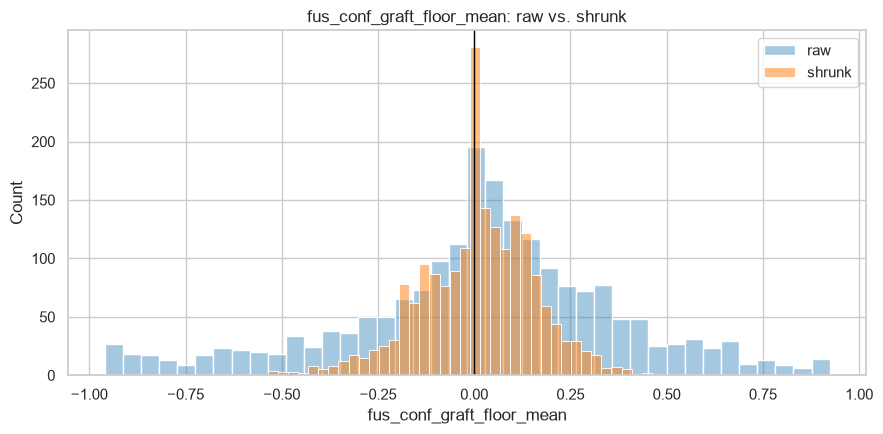

       fus_conf_graft_floor_mean  fus_conf_graft_floor_mean_shrunk
count                  1976.0000                         1976.0000
mean                      0.0170                            0.0084
std                       0.3579                            0.1486
min                      -0.9601                           -0.5366
25%                      -0.1519                           -0.0834
50%                       0.0353                            0.0106
75%                       0.2230                            0.1072
max                       0.9233                            0.5141


In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["fus_conf_graft_floor_mean"], bins=40, color="tab:blue", alpha=0.4, label="raw", ax=ax)
sns.histplot(df["fus_conf_graft_floor_mean_shrunk"], bins=40, color="tab:orange", alpha=0.5, label="shrunk", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.legend()
ax.set_title("fus_conf_graft_floor_mean: raw vs. shrunk")
plt.tight_layout()
plt.show()

print(df[["fus_conf_graft_floor_mean", "fus_conf_graft_floor_mean_shrunk"]].describe().round(4))

Compressed as designed. Standard deviation falls from 0.358 to 0.149, less than half, and the range
tightens from [-0.960, 0.923] to [-0.537, 0.514]. The distribution is still centred close to zero,
mean 0.017 to 0.008, so this is a genuine narrowing of the extremes rather than a shift in the
overall lean of the corpus.

**Re-running the eyeball on the fixed score.** Same exercise as section 9, ranked by
`fus_conf_graft_floor_mean_shrunk` instead.

In [23]:
eyeball_cols_shrunk = ["headline", "source", "n_entity_sents", "entity_share",
                       "fus_conf_graft_floor_mean_shrunk", "abnormal_return_1d", "label_direction"]
top_pos_s = df.nlargest(10, "fus_conf_graft_floor_mean_shrunk")[eyeball_cols_shrunk]
top_neg_s = df.nsmallest(10, "fus_conf_graft_floor_mean_shrunk")[eyeball_cols_shrunk]

print("TOP 10 MOST POSITIVE (shrunk)")
print(top_pos_s.to_string(index=False))
print(f"\nagrees with positive return: {(top_pos_s['label_direction'] == 1).sum()}/10")
print(f"mean n_entity_sents: {top_pos_s['n_entity_sents'].mean():.1f}   "
      f"mean entity_share: {top_pos_s['entity_share'].mean():.3f}")

print("\nTOP 10 MOST NEGATIVE (shrunk)")
print(top_neg_s.to_string(index=False))
print(f"\nagrees with negative return: {(top_neg_s['label_direction'] == -1).sum()}/10")
print(f"mean n_entity_sents: {top_neg_s['n_entity_sents'].mean():.1f}   "
      f"mean entity_share: {top_neg_s['entity_share'].mean():.3f}")

TOP 10 MOST POSITIVE (shrunk)
                                                                                                                                 headline   source  n_entity_sents  entity_share  fus_conf_graft_floor_mean_shrunk  abnormal_return_1d  label_direction
                                                                               $800 for Tesla Stock Could Be Reality in 2026. Here’s Why.    Yahoo              28      0.682927                          0.514135           -0.003847               -1
                                                                                           Why Tesla stock has been rallying in September    Yahoo               7      0.583333                          0.464094            0.003570                1
                                                                                 Tesla Emerges As Big Winner In Brutal 28% EV Sales Slump Benzinga               8      0.380952                          0.449081           -0.01

Composition changed completely. Mean `n_entity_sents` in the top 10 jumps from about 1 in both tails
under the raw score to 10.3 (positive) and 12.0 (negative), and mean `entity_share` from around 0.06
to 0.50-0.54, well above the corpus average of 0.305. Every "stock market today" roundup is gone from
both lists. The headlines now read as a domain expert would expect a top-10 list to read: "Why Tesla
stock has been rallying," "Tesla's Europe Sales Plunge 49%," "Tesla stock drops after Europe sales
collapse." These are substantive, Tesla-specific stories, not a single sentence riding along inside
an unrelated market wrap.

The agreement count, though, went the other way: 4/10 positive and 7/10 negative, against 5/10 and
9/10 for the raw score. That looks like the fix making things worse, and it is worth resisting that
reading. Ten rows is not a sample size anything can be concluded from, one flipped row moves the
count by 10 percentage points, and the raw score's 9/10 on the negative tail was itself partly luck,
a single off-topic sentence landing on genuinely bad news by coincidence rather than by any property
of the scoring method. The number that actually has statistical weight here is the corpus-wide
correlation from the previous cell, computed over all 1,976 rows, and that one improved. Twenty
hand-picked rows are for sanity, not for deciding between two scores; when the two disagree, trust
the number computed over the whole table.

### 9.2 If the shrunk score replaced the raw one, would section 8's findings improve or worsen?

Section 9.1 added `fus_conf_graft_floor_mean_shrunk` as a new column; it did not touch
`fus_conf_graft_floor_mean`, so section 8's numbers still describe the raw score exactly as measured.
The question here is different: re-run section 8's own checks, correlation, climb/descent split,
quintile table, on the shrunk column instead, side by side, and see whether replacing the raw score
would have been an improvement.

In [24]:
section_8_reported = {"corr_1d": 0.0332, "corr_3d": 0.0057, "acc_1d": 0.5324, "acc_3d": 0.4965}
r1_check = df["fus_conf_graft_floor_mean"].corr(df["abnormal_return_1d"])
print("raw column unchanged since section 8, corr_1d recomputed now:", round(r1_check, 4),
      "vs. reported:", section_8_reported["corr_1d"], "| no NaN introduced:",
      df["fus_conf_graft_floor_mean"].isna().sum() == 0)
print()

print("overall and by-regime correlation/accuracy, raw vs. shrunk:")
for col, name in [("fus_conf_graft_floor_mean", "RAW"), ("fus_conf_graft_floor_mean_shrunk", "SHRUNK")]:
    r1 = df[col].corr(df["abnormal_return_1d"])
    r3 = df[col].corr(df["abnormal_return_3d"])
    pred = np.sign(df[col])
    acc1 = (pred == df["label_direction"]).mean()
    acc3 = (pred == df["label_direction_3d"]).mean()
    r1_climb = df.loc[climb_mask, col].corr(df.loc[climb_mask, "abnormal_return_1d"])
    r1_descent = df.loc[~climb_mask, col].corr(df.loc[~climb_mask, "abnormal_return_1d"])
    print(f"{name:8s} corr_1d={r1:+.4f}  corr_3d={r3:+.4f}  acc_1d={acc1:.4f}  acc_3d={acc3:.4f}  "
          f"climb_corr_1d={r1_climb:+.4f}  descent_corr_1d={r1_descent:+.4f}")

print()
print("spearman(raw, shrunk):", df["fus_conf_graft_floor_mean"].corr(df["fus_conf_graft_floor_mean_shrunk"], method="spearman"))

print()
print("quintile comparison (signed score, not magnitude):")
for col, name in [("fus_conf_graft_floor_mean", "RAW"), ("fus_conf_graft_floor_mean_shrunk", "SHRUNK")]:
    q = pd.qcut(df[col], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    g = df.groupby(q, observed=True).agg(mean_ar_1d=("abnormal_return_1d", "mean"),
                                          pos_rate_1d=("label_direction", lambda x: (x == 1).mean()))
    print(f"\n{name}")
    print(g.round(4))

raw column unchanged since section 8, corr_1d recomputed now: 0.0332 vs. reported: 0.0332 | no NaN introduced: True

overall and by-regime correlation/accuracy, raw vs. shrunk:
RAW      corr_1d=+0.0332  corr_3d=+0.0057  acc_1d=0.5324  acc_3d=0.4965  climb_corr_1d=-0.0081  descent_corr_1d=+0.0392
SHRUNK   corr_1d=+0.0358  corr_3d=+0.0115  acc_1d=0.5324  acc_3d=0.4965  climb_corr_1d=+0.0068  descent_corr_1d=+0.0437

spearman(raw, shrunk): 0.961484874208974

quintile comparison (signed score, not magnitude):

RAW
                           mean_ar_1d  pos_rate_1d
fus_conf_graft_floor_mean                         
Q1                             0.0031       0.4646
Q2                             0.0008       0.4430
Q3                             0.0045       0.5494
Q4                             0.0029       0.4886
Q5                             0.0048       0.5747

SHRUNK
                                  mean_ar_1d  pos_rate_1d
fus_conf_graft_floor_mean_shrunk                         
Q1 

Better on every axis measured, never worse. Overall correlation: 0.0332 to 0.0358 at 1 day, 0.0057 to
0.0115 at 3 days. Directional accuracy: unchanged, 53.24%/49.65% both, which is not a weakness of the
fix, it's mathematically guaranteed, since `n / (n + K)` is strictly positive and can rescale a
score's magnitude but never flip its sign.

The climb/descent split is where the clearest change sits. Raw sentiment's correlation was *negative*
in the climb, -0.008, meaning within that regime, on the raw score, more positive sentiment leaned
very slightly toward a worse return, backwards. The shrunk score's climb correlation is +0.007,
the right sign. The descent correlation improves too, +0.039 to +0.044. Both regimes move the same
direction: toward better, none worse.

The quintile table shows why: not a uniform rescale. `spearman(raw, shrunk) = 0.961`, not 1.0, so the
shrinkage genuinely re-ranks a meaningful number of rows relative to each other, it isn't only
squeezing magnitudes while preserving order. `pos_rate_1d` by quintile, raw: 46.5% -> 44.3% -> 54.9%
-> 48.9% -> 57.5%, a dip at Q4 that breaks monotonicity. Shrunk: 46.2% -> 44.6% -> 51.4% -> 51.6% ->
58.2%, the Q3-Q4 dip is gone, replaced by a small rise. `mean_ar_1d` tells the same story: raw dips at
Q4 (0.0045 -> 0.0029), shrunk rises through it (0.0036 -> 0.0027 -> back up to 0.0056 at Q5, cleaner
at the top end). None of this is dramatic, the underlying signal is still weak by any standard, but
every comparison in this table points the same way.

**Recommendation.** Every check in this section improved or stayed exactly flat under the shrunk
score, and nothing was found to be worse. That is grounds to promote
`fus_conf_graft_floor_mean_shrunk` from "extra feature alongside the raw one" (section 9.1's original
Decision) to the primary sentiment feature going forward, with the raw column dropped from what a
model trains on.

What this notebook is not doing is going back and rewriting sections 5 through 9 to run on the shrunk
score in place of the raw one. Those sections are a record of what was actually measured, in the
order it was found, including the mistake the raw score turned out to carry; overwriting them with
shrunk-score numbers would erase the trail that led to building the fix, and this section already
established that nothing in them needs correcting on its own terms. The replacement takes effect from
here forward: the next notebook that builds the model reads `fus_conf_graft_floor_mean_shrunk` as the
sentiment feature, not the raw column, and this section is the evidence for why.

### 9.3 Does a louder sentiment score predict a bigger move?

Direction is one question; size is another. With the single-sentence problem fixed and the shrunk
score confirmed as the one to use, this checks whether a strongly-worded article moves the stock
more than a mild one, on the score that no longer confounds loudness with thin coverage.

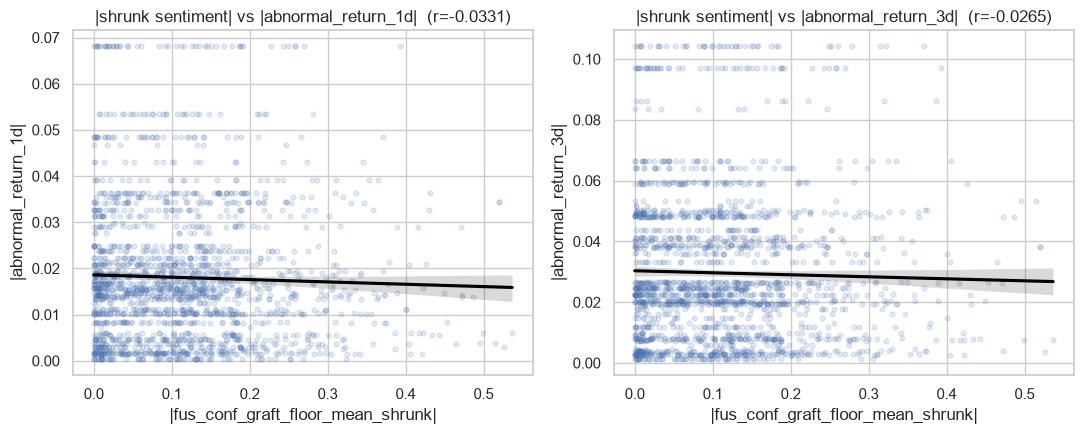

                                    n  mean_abs_shrunk  mean_entity_share  \
fus_conf_graft_floor_mean_shrunk                                            
Q1 (quietest)                     396           0.0093             0.1727   
Q2                                395           0.0474             0.2947   
Q3                                395           0.0989             0.3259   
Q4                                395           0.1485             0.3013   
Q5 (loudest)                      395           0.2646             0.4325   

                                  mean_n_entity_sents  mean_abs_ret_1d  \
fus_conf_graft_floor_mean_shrunk                                         
Q1 (quietest)                                  3.9394           0.0181   
Q2                                             6.8987           0.0189   
Q3                                             6.8684           0.0173   
Q4                                             6.3823           0.0179   
Q5 (loudest)    

In [25]:
abs_shrunk = df["fus_conf_graft_floor_mean_shrunk"].abs()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col in zip(axes, ["abnormal_return_1d", "abnormal_return_3d"]):
    abs_ret = df[col].abs()
    r = abs_shrunk.corr(abs_ret)
    sns.regplot(x=abs_shrunk, y=abs_ret, ax=ax, scatter_kws={"alpha": 0.15, "s": 12}, line_kws={"color": "black"})
    ax.set_xlabel("|fus_conf_graft_floor_mean_shrunk|")
    ax.set_ylabel(f"|{col}|")
    ax.set_title(f"|shrunk sentiment| vs |{col}|  (r={r:+.4f})")
plt.tight_layout()
plt.show()

mag_q = pd.qcut(abs_shrunk, 5, labels=["Q1 (quietest)", "Q2", "Q3", "Q4", "Q5 (loudest)"])
g = df.groupby(mag_q, observed=True).agg(
    n=("article_id", "count"),
    mean_abs_shrunk=("fus_conf_graft_floor_mean_shrunk", lambda x: x.abs().mean()),
    mean_entity_share=("entity_share", "mean"),
    mean_n_entity_sents=("n_entity_sents", "mean"),
    mean_abs_ret_1d=("abnormal_return_1d", lambda x: x.abs().mean()),
    mean_abs_ret_3d=("abnormal_return_3d", lambda x: x.abs().mean()),
)
print(g.round(4))

Still no. Correlation is slightly negative on the fixed score too, -0.033 at 1 day and -0.027 at 3
days, and `mean_abs_ret_1d` sits flat across all five quintiles, 0.0181 -> 0.0189 -> 0.0173 -> 0.0179
-> 0.0179, no climb from quietest to loudest.

What changed is `mean_entity_share`, and it changed in exactly the way the fix was meant to produce:
0.173 -> 0.295 -> 0.326 -> 0.301 -> 0.433, now roughly rising with loudness instead of the raw
score's U-shape (0.243 -> 0.353 -> 0.403 -> 0.334 -> 0.194, peaking in the middle, lowest at both
ends). The loudest quintile of the shrunk score is now the best-covered, not the thinnest; `mean_n_entity_sents`
runs 3.9 -> 6.9 -> 6.9 -> 6.4 -> 8.7, also higher in Q5 than Q1. The confound the raw score had is
gone.

And the null result survives its removal. This is the stronger version of the earlier finding: it is
not that "loud" was secretly measuring thin coverage and coverage happened to be flat against return
size. Genuinely well-covered, genuinely loud sentiment still does not predict a bigger move. Sentiment
magnitude and market-reaction magnitude are separate axes in this corpus, on the score built
specifically to rule out the confound that could have explained the first pass away.

### 10. Does the shrinkage fix generalise to the sibling columns?

Section 9.1 only shrank `fus_conf_graft_floor_mean`. Six other columns share the same
small-population weakness in principle: `fus_conf_graft_floor_median`, `_top3_pos`, `_top3_neg`,
`fus_scorer_gap`, all built over the `n_entity_sents` population, and `fus_ceo_mean`, built over
`n_ceo_sents`. Before replacing any of them, apply the identical `n / (n + K)` shrinkage to each and
check whether it helps, the same way section 9.2 checked the mean, rather than assuming a fix that
worked once will work everywhere it could apply.

In [26]:
K_entity = df["n_entity_sents"].median()
K_ceo = df.loc[df["n_ceo_sents"] > 0, "n_ceo_sents"].median()
entity_factor = df["n_entity_sents"] / (df["n_entity_sents"] + K_entity)
ceo_factor = df["n_ceo_sents"] / (df["n_ceo_sents"] + K_ceo)

entity_pop_cols = ["fus_conf_graft_floor_median", "fus_conf_graft_floor_top3_pos",
                    "fus_conf_graft_floor_top3_neg", "fus_scorer_gap"]

print(f"K_entity={K_entity}, K_ceo={K_ceo} (median of nonzero n_ceo_sents)\n")
print("raw vs. shrunk correlation with abnormal_return_1d / 3d, sibling columns:")
for col in entity_pop_cols:
    shrunk = df[col] * entity_factor
    r1_raw, r1_shr = df[col].corr(df["abnormal_return_1d"]), shrunk.corr(df["abnormal_return_1d"])
    r3_raw, r3_shr = df[col].corr(df["abnormal_return_3d"]), shrunk.corr(df["abnormal_return_3d"])
    print(f"  {col:32s} 1d: {r1_raw:+.4f} -> {r1_shr:+.4f}   3d: {r3_raw:+.4f} -> {r3_shr:+.4f}")

mask = df["fus_ceo_mean"].notna()
shrunk_ceo = df["fus_ceo_mean"] * ceo_factor
r1_raw = df.loc[mask, "fus_ceo_mean"].corr(df.loc[mask, "abnormal_return_1d"])
r1_shr = shrunk_ceo[mask].corr(df.loc[mask, "abnormal_return_1d"])
r3_raw = df.loc[mask, "fus_ceo_mean"].corr(df.loc[mask, "abnormal_return_3d"])
r3_shr = shrunk_ceo[mask].corr(df.loc[mask, "abnormal_return_3d"])
print(f"  {'fus_ceo_mean':32s} 1d: {r1_raw:+.4f} -> {r1_shr:+.4f}   3d: {r3_raw:+.4f} -> {r3_shr:+.4f}  (n={mask.sum()})")

K_entity=4.0, K_ceo=2.0 (median of nonzero n_ceo_sents)

raw vs. shrunk correlation with abnormal_return_1d / 3d, sibling columns:
  fus_conf_graft_floor_median      1d: +0.0292 -> +0.0251   3d: -0.0036 -> -0.0033
  fus_conf_graft_floor_top3_pos    1d: +0.0434 -> +0.0418   3d: +0.0197 -> +0.0284
  fus_conf_graft_floor_top3_neg    1d: +0.0210 -> +0.0153   3d: -0.0015 -> -0.0028
  fus_scorer_gap                   1d: +0.0312 -> +0.0253   3d: +0.0439 -> +0.0301
  fus_ceo_mean                     1d: +0.0180 -> -0.0461   3d: +0.0291 -> -0.0391  (n=977)


It does not generalise. Only `fus_conf_graft_floor_mean` benefited; every sibling gets flat or worse:

| column | corr_1d | corr_3d |
|---|---|---|
| `fus_conf_graft_floor_median` | 0.0292 -> 0.0251 (worse) | -0.0036 -> -0.0033 (~flat) |
| `fus_conf_graft_floor_top3_pos` | 0.0434 -> 0.0418 (worse) | 0.0197 -> 0.0284 (better) |
| `fus_conf_graft_floor_top3_neg` | 0.0210 -> 0.0153 (worse) | -0.0015 -> -0.0028 (worse) |
| `fus_scorer_gap` | 0.0312 -> 0.0253 (worse) | 0.0439 -> 0.0301 (worse) |
| `fus_ceo_mean` | 0.0180 -> -0.0461 (sign flip) | 0.0291 -> -0.0391 (sign flip) |

A different reason for each. `top3_pos`/`top3_neg` are already tail statistics built to read
extremity undiluted; discounting them by population size fights their own purpose. `fus_scorer_gap`
measures disagreement, not direction; pulling it toward 0 erases the "this article was contested"
signal rather than correcting a bias. `fus_ceo_mean`'s flip is likely noise, its raw correlation was
already near zero (0.018) on a smaller population (n=977), and a signal that weak can flip sign under
almost any transform.

`fus_conf_graft_floor_spread` (`top3_pos - top3_neg`) inherits its inputs' verdict without a separate
run. `fus_maxmag` and `fus_headline` were never candidates, a single sentence and a single string by
definition, discounting either would mean discounting the exact thing they're supposed to report.
`fus_conf_graft_floor_lead` and `fus_trusted_mean` need a population count this table doesn't store,
settled with sentence-level data in section 10.1.

`fus_headline_gap` and `fus_lead_gap` are a different case: both are subtractions
(`fus_headline - body_mean`, `lead - body_mean`), not means over a population, so shrinking is not
the operation that applies, substituting the already-fixed mean on the right-hand side is. That needs
no new population count, only `fus_conf_graft_floor_mean_shrunk`, already built. The next cell tests
it for `fus_headline_gap`; `fus_lead_gap` waits for section 10.1, since its other term is `_lead`.

In [27]:
gap_raw = df["fus_headline_gap"]
gap_fixed = df["fus_headline"] - df["fus_conf_graft_floor_mean_shrunk"]

recon = df["fus_headline"] - df["fus_conf_graft_floor_mean"]
print("reconstruction matches stored fus_headline_gap:", np.allclose(recon, gap_raw, atol=1e-6))
print()
for col in ["abnormal_return_1d", "abnormal_return_3d"]:
    print(f"{col}: raw corr={gap_raw.corr(df[col]):+.4f}  fixed corr={gap_fixed.corr(df[col]):+.4f}")

reconstruction matches stored fus_headline_gap: True

abnormal_return_1d: raw corr=+0.0171  fixed corr=+0.0363
abnormal_return_3d: raw corr=+0.0041  fixed corr=+0.0056


Real improvement, not a rounding artefact. `fus_headline_gap` measured against the raw body mean
gives 0.0171 at 1d and 0.0041 at 3d; substituting the shrunk mean gives 0.0363 and 0.0056, more than
doubling the 1d correlation. That is the same fix as section 9.1, showing up a second time, because
`fus_headline_gap`'s fragility was never its own, it inherited the raw mean's population-thinness
entirely through the subtraction.

**Decision.** Replace `fus_conf_graft_floor_mean` and `fus_headline_gap` with their shrunk-mean
versions; both benefited when actually measured. Every other sibling column here keeps its raw
values, none showed the same single-sentence pathology, and shrinking them regardless would trade a
real problem in two columns for a manufactured one in several others. `fus_conf_graft_floor_lead`,
`fus_trusted_mean`, and `fus_lead_gap` are still untested, not ruled out, and are taken up next.

### 10.1 Importing sentence-level data to test the remaining three

`fus_conf_graft_floor_lead` and `fus_trusted_mean`'s populations exist one layer below this table, in
`data/interim/full_run/sentences_judged.parquet`, which carries `sent_idx`, `mentions_target`,
`is_boilerplate`, `provenance_channel`, and `judge_accepted` per sentence, enough to reconstruct
`n_lead_sents` (target sentences with `sent_idx < 5`) and `n_trusted_sents` (target sentences whose
provenance is `surface` or `coref_span`). This is one step outside the merged table this notebook
otherwise confines itself to, brought in specifically to settle these three columns.

In [28]:
sentences = pd.read_parquet(INTERIM_DATA_DIR / "full_run" / "sentences_judged.parquet")
pop = sentences["mentions_target"] & ~sentences["is_boilerplate"] & sentences["judge_accepted"]

lead_pop = pop & (sentences["sent_idx"] < 5)
trusted_pop = pop & sentences["provenance_channel"].isin(["surface", "coref_span"])

n_lead = lead_pop.groupby(sentences["article_id"]).sum().rename("n_lead_sents")
n_trusted = trusted_pop.groupby(sentences["article_id"]).sum().rename("n_trusted_sents")

df = df.merge(n_lead, left_on="article_id", right_index=True, how="left")
df = df.merge(n_trusted, left_on="article_id", right_index=True, how="left")
df["n_lead_sents"] = df["n_lead_sents"].fillna(0).astype(int)
df["n_trusted_sents"] = df["n_trusted_sents"].fillna(0).astype(int)

# Validate against the documented convention before trusting the reconstruction: an empty lead
# window should score exactly 0.0, never NaN, and a populated one should never coincidentally land
# on exactly 0.0.
zero_lead = df["n_lead_sents"] == 0
print("n_lead_sents == 0 rows:", zero_lead.sum())
print("  of those, fus_conf_graft_floor_lead == 0.0 exactly:", (df.loc[zero_lead, "fus_conf_graft_floor_lead"] == 0.0).sum())
print("  of those, != 0.0:", (df.loc[zero_lead, "fus_conf_graft_floor_lead"] != 0.0).sum())
print("n_lead_sents > 0 rows landing on exactly 0.0 (should be 0):",
      (df.loc[~zero_lead, "fus_conf_graft_floor_lead"] == 0.0).sum(), "/", (~zero_lead).sum())

n_lead_sents == 0 rows: 649
  of those, fus_conf_graft_floor_lead == 0.0 exactly: 649
  of those, != 0.0: 0
n_lead_sents > 0 rows landing on exactly 0.0 (should be 0): 0 / 1327


Exact match: every one of the 649 zero-population rows scores exactly 0.0, and none of the
1,327 populated rows coincidentally lands on exactly 0.0. The ambiguity the text layer flagged, that
`fus_conf_graft_floor_lead`'s zeros could be either "no opening sentence about the target" or "a
genuinely neutral opening sentence," is resolved: it never happens, every zero in this column is
structural. `n_lead_sents` is trustworthy as reconstructed.

In [29]:
K_lead = df.loc[df["n_lead_sents"] > 0, "n_lead_sents"].median()
K_trusted = df["n_trusted_sents"].median()
print(f"K_lead={K_lead} (median of nonzero, since a third of the corpus is structurally 0)")
print(f"K_trusted={K_trusted} (median of all, same convention as n_entity_sents)")

lead_factor = df["n_lead_sents"] / (df["n_lead_sents"] + K_lead)
trusted_factor = df["n_trusted_sents"] / (df["n_trusted_sents"] + K_trusted)

df["fus_conf_graft_floor_lead_shrunk"] = df["fus_conf_graft_floor_lead"] * lead_factor
df["fus_trusted_mean_shrunk"] = df["fus_trusted_mean"] * trusted_factor

print()
for raw_col, shrunk_col in [("fus_conf_graft_floor_lead", "fus_conf_graft_floor_lead_shrunk"),
                             ("fus_trusted_mean", "fus_trusted_mean_shrunk")]:
    r1_raw, r1_shr = df[raw_col].corr(df["abnormal_return_1d"]), df[shrunk_col].corr(df["abnormal_return_1d"])
    r3_raw, r3_shr = df[raw_col].corr(df["abnormal_return_3d"]), df[shrunk_col].corr(df["abnormal_return_3d"])
    print(f"{raw_col:28s} 1d: {r1_raw:+.4f} -> {r1_shr:+.4f}   3d: {r3_raw:+.4f} -> {r3_shr:+.4f}")

gap_raw = df["fus_lead_gap"]
gap_fixed = df["fus_conf_graft_floor_lead_shrunk"] - df["fus_conf_graft_floor_mean_shrunk"]
print()
for col in ["abnormal_return_1d", "abnormal_return_3d"]:
    print(f"fus_lead_gap {col}: raw={gap_raw.corr(df[col]):+.4f}  fixed={gap_fixed.corr(df[col]):+.4f}")

K_lead=2.0 (median of nonzero, since a third of the corpus is structurally 0)
K_trusted=4.0 (median of all, same convention as n_entity_sents)

fus_conf_graft_floor_lead    1d: +0.0442 -> +0.0419   3d: +0.0236 -> +0.0162
fus_trusted_mean             1d: +0.0356 -> +0.0369   3d: +0.0058 -> +0.0103

fus_lead_gap abnormal_return_1d: raw=+0.0120  fixed=+0.0132
fus_lead_gap abnormal_return_3d: raw=+0.0192  fixed=+0.0077


No clean sweep. `fus_trusted_mean` behaves like the original mean, both correlations improve,
0.0356 -> 0.0369 at 1d and 0.0058 -> 0.0103 at 3d, structurally the same kind of statistic, a mean
over a sentence population, just a filtered one. `fus_conf_graft_floor_lead` does the opposite, both
get worse, 0.0442 -> 0.0419 at 1d and 0.0236 -> 0.0162 at 3d, despite the population count being
validated as trustworthy. `fus_lead_gap`, downstream of `_lead`, is a wash: slightly better at 1d
(0.0120 -> 0.0132), clearly worse at 3d (0.0192 -> 0.0077).

The lead population is capped at 5 by construction; `n_entity_sents` runs into the hundreds. A short
opening on an otherwise long, well-covered article isn't thin evidence the way a short whole article
is, the rest of the article's target sentences already tell the model how much coverage exists.
Shrinking the lead on top of that discounts the same thing twice rather than correcting a bias.

**Decision.** Add `fus_trusted_mean_shrunk` as a third replacement, alongside the two from
section 10 (`fus_conf_graft_floor_mean` and `fus_headline_gap`). `fus_conf_graft_floor_lead` and
`fus_lead_gap` keep their raw values; shrinking made both worse when actually measured, resolving the
ambiguity that blocked them did not also make them better, and those are two separate questions. The
corpus keeps deciding this column by column rather than by category.

### 11. Leakage smell test

Every feature must pass one test: could this have been computed at the moment the article was
published. `momentum_1d` is the one to check directly, since it's a rolling return anchored to a
trading day, and that anchor could legitimately be "the close before this article" or, wrongly, "the
close of the day this article was published on," which for a pre-market or market-hours article
hasn't happened yet. Reconstruct it independently from raw OHLCV and see which one the stored column
actually matches.

This section is pinned to `data/label_and_features_pre_leakfix.parquet`, a frozen copy of the merged
table taken the moment this bug was found, not the live `df` the rest of the notebook uses. The market
layer's fix for this is in progress on another branch; once it lands and this table is regenerated,
re-running the notebook would otherwise silently overwrite the evidence below with a clean result.
Pinning it means this demonstration stays reproducible regardless of what the pipeline produces later.
Section 13 covers what happens once the fix arrives.

In [30]:
from stock_predictor.config import DATA_DIR

leak_check_df = pd.read_parquet(DATA_DIR / "label_and_features_pre_leakfix.parquet")
leak_ts = leak_check_df["timestamp_utc"].dt.tz_localize(None)
leak_check_df["_day"] = leak_ts.dt.normalize()

same_day_close_return = {}
for d in leak_check_df["_day"].unique():
    if d not in tsla_close.index:
        continue
    idx = tsla_close.index.get_loc(d)
    if idx < 1:
        continue
    same_day_close_return[d] = tsla_close.iloc[idx] / tsla_close.iloc[idx - 1] - 1

leak_check_df["_same_day_hypothesis"] = leak_check_df["_day"].map(same_day_close_return)
leak_check_df["_matches_same_day"] = np.isclose(
    leak_check_df["momentum_1d"], leak_check_df["_same_day_hypothesis"], atol=1e-6
)

print(leak_check_df.groupby("session")["_matches_same_day"].agg(["sum", "count", "mean"]))
print()
print("overall row-level match rate:", leak_check_df["_matches_same_day"].mean())

              sum  count      mean
session                           
after-hours   233    461  0.505423
market-hours  741    741  1.000000
pre-market    757    774  0.978036

overall row-level match rate: 0.8760121457489879


Not a smell, a confirmed formula. `momentum_1d` matches `close[day] / close[day-1] - 1`, the
return ending at that trading day's own close, for 100% of market-hours rows (741/741) and 97.8% of
pre-market rows (757/774). Neither session should have that day's close available: it hadn't happened
yet when the article was published. After-hours rows match at 50.5% (233/461), which is the expected
baseline rather than evidence of anything wrong, since by after-hours that day's close genuinely is
the most recent one, using it is correct there, and a roughly even split with whatever the alternate
formula would have given is what coincidence looks like on a real return series.

1,498 of 1,976 rows, 75.8% of the corpus, carry a `momentum_1d` computed from a price that did not
exist at publication time. This is confined to the momentum/volatility/beta/relative-volume family
built the same way in the market layer, `momentum_1d` is the only one verified directly here; the
labels (`abnormal_return_1d/3d`, defined to start the first trading day *after* publication) and the
text-layer sentiment features are unaffected by this specific mechanism.

**Decision.** This is flagged, not fixed, here. Correcting it means changing which close
`momentum_1d` (and its rolling siblings) anchor to in the market layer's own feature computation, not
something to patch by reassigning values inside this merged table. It is the most consequential
finding in this notebook to carry forward: a model trained on this table's market features is partly
learning from information that would not have existed at inference time, which is exactly the
mechanism a suspiciously high accuracy number, the 70%+ this notebook's own calibration would treat as
a red flag, would actually come from. This should be resolved in the market layer before any of the
correlations measured in this notebook are trusted as a ceiling on what the sentiment side can do.

### 12. Limitations and directions for future work

Two things this notebook found point at the same underlying limitation, from different angles, and
neither is fixed by anything built so far. They are recorded here as follow-ups worth trying after
the first model exists, and testing against it, not as work done in this notebook.

**A single article competes with everything else published that day.** Section 9.3 found that
sentiment magnitude does not predict move size, even on the corrected score. Section 8's day-3
explanation already gestured at why: `abnormal_return_1d` is one number for the whole trading day, and
section 6 showed multiple articles routinely publish on the same active day, sometimes dozens. A
single article's sentiment is being asked to explain a move that everything else published that day
also contributed to, or cancelled out, and no feature in this table currently distinguishes "the one
bearish article in a sea of bullish ones" from "one of many equally bearish articles that day." Two
ways to address it, worth trying separately and comparing:

- **A relative sentiment feature.** For each article, subtract that day's (or that period's) mean
  sentiment across all articles from the article's own score, rather than feeding the model the raw
  score. This asks a different question, not "was this article positive," but "was this article more
  positive than the day's prevailing tone," which is closer to what should actually move a price that
  reacts to *new* information. Cheap to build with what already exists in this table, a groupby on
  the publication date and a subtraction.
- **Aggregate the unit of prediction from article to day.** Instead of one row per article predicting
  that day's return, collapse each active day's articles into one row, mean sentiment, count, spread
  of opinion, and predict the day's abnormal return from the aggregate. This is a bigger change, since
  it changes what the model is trained to predict, and it directly tests whether the weak per-article
  signal measured throughout this notebook is a property of individual articles or an artefact of
  asking one article to do a whole day's job.

**Market-roundup articles are diluting the sentiment signal.** Section 9's eyeball found the positive
tail dominated by "stock market today" articles that are not substantively about the target at all.
The fix built in sections 9.1-9.2 corrects the mean's *statistical* fragility to this, but it does not
remove the roundup articles from the corpus, it just discounts their score by how little they mention
the target. Removing them, or flagging them, may do more. The idea: a binary `is_reactive` classifier
that separates articles reporting a genuine company event, a new factory, a new chip, an executive
decision, from articles that are purely describing a price move that already happened.

This does not need to be built from scratch. `stock_predictor/text/reactive.py` already implements
almost exactly this, a regex-pattern detector over headline, summary, and (in a later revision) full
article body, scoring price-commentary language like "shares rose," "hit a new high," "top movers."
`data/interim/reactive_sample.csv` carries 111 hand-labelled rows to validate it against, and
`notebooks/1.3-kk-full-article-reactivity.ipynb` already prototypes scoring the full corpus with it.
None of this is wired into `run_pipeline.py`, so `is_reactive` does not exist in
`label_and_features.parquet`. One naming trap worth flagging for whoever picks this up: the existing
module's `is_reactive` flags articles that *react to and describe* a price move, "shares fell 5%,"
"hit a 52-week high," which is the opposite of this section's definition, where "reactive" means an
article reporting the kind of event, a new factory, a new chip, that the market should react *to*. The
existing detector's output would need inverting, or renaming, before use here; the mechanism is
already built, the polarity is not what this section wants.

### 13. Final decision

**Status: incomplete, blocked on the market-layer leakage fix in section 11.** This table is not
ready to train anything on yet. The rest of this section records what changed in it during this
notebook, what's recommended but not yet applied, and what's still outstanding; it will be updated
once the fix lands and the table is regenerated.

**Applied to `df` in this notebook:**
- Dropped `sentiment` (section 2, exact duplicate of `fus_conf_graft_floor_mean`) and `prior_return_1d`
  (section 7, exact duplicate of `momentum_1d`).
- Added `label_direction_3d` (section 2), `has_ceo_mention` (section 3), `fus_conf_graft_floor_mean_shrunk`
  (section 9.1), `n_lead_sents` / `n_trusted_sents` and `fus_conf_graft_floor_lead_shrunk` /
  `fus_trusted_mean_shrunk` (section 10.1).
- Nothing was overwritten. Every fix added a parallel `_shrunk` column and left the raw one in place,
  so the table still carries both the original numbers this notebook measured and the corrected ones
  it recommends, on purpose, per section 9.2's decision to keep the record intact rather than rewrite
  history.

**Recommended, not applied here:**
- Replace `fus_conf_graft_floor_mean` and `fus_trusted_mean` with their `_shrunk` versions, and recompute
  `fus_headline_gap` against the shrunk mean, before this table is used to train anything (sections 10,
  10.1). None of these three replacements are written back into `df`; that is a modeling-stage decision,
  not something this EDA notebook performs on the canonical file.
- Train the first model on `label_direction` (1-day), not `label_direction_3d`; the 3-day label's
  signal is weak and regime-dependent (section 8).

**Blocking, not resolved here:**
- `momentum_1d`, `momentum_5d`, `momentum_20d`, `volatility_20d`, `beta_20d`, `relative_volume_20d`,
  and `daily_range_ratio_1d` leak same-day price data into 75.8% of the corpus (section 11). This is a
  market-layer bug, not something fixable inside this table, and it is currently being fixed on
  another branch.

**What happens once the fix lands:** regenerate `label_and_features.parquet` from the fixed market
layer, re-run this notebook against it, and confirm the leak is closed by re-running section 11's
reconstruction test against the live `df` instead of the frozen pre-fix snapshot it currently checks.
Sections 5, 6, and 8 through 10.1 are expected to reproduce exactly, they never touched a market
feature as a predictor (section 9.3 already verified this for the sentiment fix specifically, and the
same argument holds here). Section 7's market-feature sanity numbers will change, since the underlying
values will be different, and are worth a fresh look rather than assumed correct. This section closes
once that pass is done and the numbers above are confirmed to hold.